In [1]:
#importing libraries
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
# import scipy
# import pandas as pd

# Q1


$$ 2x + 2y = 8$$
$$ -x + 2y = 4$$

solve for x and y

In [9]:
#coefficient
A = np.array([
    [2,2],
    [-1,2]
])

#constants
b = np.array([8,4])

M = np.hstack((A, b.reshape(-1,1)))


symMat = sym.Matrix(M)

#before solving the matrix i will check how many solutions the system

rank_A = np.linalg.matrix_rank(A)
rank_aug = np.linalg.matrix_rank(M)  # M is the augmented matrix [A|b]
n_unknowns = A.shape[1]

print(f"rank A: = {rank_A}")
print(f"rank [A|b] = {rank_aug}")
print(f"number of unknowns = {n_unknowns}")


if rank_aug > rank_A:
  print(
    "0 solutions: rank([A|b]) > rank(A), ",
    "so b cannot be expressed as a linear combination of A's columns"
  )
elif rank_aug == rank_A == n_unknowns:
  print(
    "1 solution: rank([A|b]) = rank(A) = number of unknowns, ",
    "so all variables are a unique linear combination of A's columns"
  )
elif rank_aug == rank_A < n_unknowns:
  print(
    "Infinitely many solutions: rank([A|b]) = rank(A) < number of unknowns, "
    "so at least one variable is free. fx. x + y = 10"
  )


#from this we know there is one solution

S = symMat.rref()[0]
print(S)


x = S[0,2]
y = S[1,2]

print()
print(f"x = {x}, y = {y}")
print()
print("checking the solution:")
print(f"2x + 2y = {2*x + 2*y} (should be 8)")
print(f"-1x + 2y = {-1*x + 2*y} (should be 4)")

print("now it is confirmed that the solution is correct.")
print("\33[32mSolution:\033[0m")
print(f"x = {x}\ny = {y}")

rank A: = 2
rank [A|b] = 2
number of unknowns = 2
1 solution: rank([A|b]) = rank(A) = number of unknowns,  so all variables are a unique linear combination of A's columns
Matrix([[1, 0, 4/3], [0, 1, 8/3]])

x = 4/3, y = 8/3

checking the solution:
2x + 2y = 8 (should be 8)
-1x + 2y = 4 (should be 4)
now it is confirmed that the solution is correct.
Solution:
x = 4/3
y = 8/3


# Q2
Diagonalize

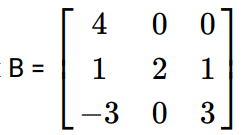


and print  V, D and inv(V)



use V, D and inv(V) to show the diagonalization is correct

In [18]:
B = np.array([
    [4,0,0],
    [1,2,1],
    [-3,0,3],
])
#diagonalize B
eigenvalues, eigenvectors = np.linalg.eig(B)

V = eigenvectors
D = np.diag(eigenvalues)

V_inv = np.linalg.inv(V)

print("\33[32m1) Printouts:\033[0m")
print("V = \n", np.round(V,2))
print("\nD = \n", np.round(D,2))
print("\ninv(V) = \n", np.round(V_inv,2))




# use V, D and inv(V) to show the diagonalization is correct
print("\n\n\33[32m2) Diagonalization check:\033[0m")
B_reconstructed = V @ D @ V_inv
print("\nB_reconstructed = \n", np.round(B_reconstructed,2))
print("\nOriginal B = \n", np.round(B,2))
print("\nCheck if B_reconstructed is close to B: ", np.allclose(B, B_reconstructed))






1) Printouts:
V = 
 [[ 0.    0.    0.3 ]
 [ 1.    0.71 -0.3 ]
 [ 0.    0.71 -0.9 ]]

D = 
 [[2. 0. 0.]
 [0. 3. 0.]
 [0. 0. 4.]]

inv(V) = 
 [[-2.    1.   -1.  ]
 [ 4.24  0.    1.41]
 [ 3.32  0.    0.  ]]


2) Diagonalization check:

B_reconstructed = 
 [[ 4.  0.  0.]
 [ 1.  2.  1.]
 [-3.  0.  3.]]

Original B = 
 [[ 4  0  0]
 [ 1  2  1]
 [-3  0  3]]

Check if B_reconstructed is close to B:  True


# Q3

1. Compute the SVD of matrix B. Print the resulting U, S, V^T matrices.
2. Use U, S, V^T to reconstruct the original matrix B and check the two matrices are the same.

In [19]:
U, s, Vt = np.linalg.svd(B)

print("\33[32m3) SVD:\033[0m")
print("U = \n", np.round(U,2))
print("\nS = \n", np.round(s,2))
print("\nV^T = \n", np.round(Vt,2))

print("\n\n")

# Reconstruct B using U, S, and V^T
S_matrix = np.diag(s)
B_reconstructed_svd = U @ S_matrix @ Vt
print("B_reconstructed = \n", np.round(B_reconstructed_svd,2))
print("\nOriginal B = \n", np.round(B,2))
print("\nCheck if B_reconstructed is close to B: ", np.allclose(B, B_reconstructed_svd))

3) SVD:
U = 
 [[-0.68 -0.42  0.6 ]
 [-0.12 -0.74 -0.66]
 [ 0.72 -0.52  0.46]]

S = 
 [5.42 2.88 1.54]

V^T = 
 [[-0.92 -0.04  0.38]
 [-0.3  -0.52 -0.8 ]
 [ 0.23 -0.85  0.47]]



B_reconstructed = 
 [[ 4. -0.  0.]
 [ 1.  2.  1.]
 [-3.  0.  3.]]

Original B = 
 [[ 4  0  0]
 [ 1  2  1]
 [-3  0  3]]

Check if B_reconstructed is close to B:  True


# Q4

Given that we obtained a SVD decomposition of a matrix $$A = UΣV^T$$ where the singular values are $$σ_1 ≥ σ_2 ≥ ... ≥ σ_r$$ where $$2 < k < r$$
1. What mathematical expression shows that the reconstruction of A is the sum of all the rank-1 layers of the SVD?
2. Defne in your own words what is a low-rank approximation of A?

1) it is given by the expression
$$A = \sum_{i=1}^{r} \sigma_i u_i v_i^T $$
this sums up alle the layers:
$$ \sigma_i u_i v_i^T $$
here the layer is composed of the singular value and the outer product of the corresponding left and right singular vectors.

2) 
a low rank approximation of A is when only the most significant layers are used, so instead og summing up all the layers
$$A = \sum_{i=1}^{r} \sigma_i u_i v_i^T $$
only the most significant layers are used, this makes a approximation of A, but not the exact A as some information is lost
an expression for this is:
$$A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^T $$
i can help with noise reduction ond compression of data